# 3.15 Pointing --VIS PSF Mapping

OVERVIEW: Acquire data to measure the visible array's Point Spread Function (PSF) as a function of array location and source temperature. Observe two moderately bright stars in a uniform pattern at 13 locations across the array. The stars should have different temperatures: a cooler star of ~_(?)_ K and a hotter star of ~_(?)_ K.


DATA PRODUCT: 
- RD-B1: create a PSF shape data cube 
    
    
EXIT CRITERIA: observations obtained, analysis complete and summarized in 3.15_ResultsSummary.md


DATA VOLUME: 13 VIS observations with targets positioned at different point on the array, For each observation we save two 200x200 pixel regions of interest


TARGET CRITERIA: Two stars of temps ~_(?)_ K and ~_(?)_ K in the same VIS FOV. These criteria will be further updated with input from the stakeholders.


KEY STAKEHOLDERS: Christina Hedges, Rae Holcomb

### Load In

In [1]:
''' Make sure you have pandorasim installed and updated '''
import pandorasat as ps
import pandorasim as pp
ps.utils.get_phoenix_model(teff=7000, jmag=10) # this is a temporary fix to an import error with pandorasim
from pandorasim import VisibleSim, NIRSim
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, VIS_ra_shape, VIS_dec_shape


In [2]:
''' Define a PandoraSat object for calling constants '''
p = ps.PandoraSat()

## Define Array Location Function

In [3]:
''' Function defining the pattern of the target location on the array '''
### This function returns a location to point the telescope [in degrees] given an observation id number.
# We will update this function to adjust the pattern based on input from the stakeholders.
# We currently assume that the "home" location is with one of our two targets in the center. 
# (ra, dec)=(10,10)deg is only a default for visualization in the next cell.
###


### Set the number of observations here
num_observations = 13 

# def array_location(obsid_num, ra_home=10*u.degree, dec_home=10*u.degree):
    
#     ra_home = ra_home
#     dec_home = dec_home
#     VIS_shape_deg = VIS_ra_shape.to(u.degree) ### Shape of the array in degrees. RA and Dec are the same.
    
#     ### center 
#     if obsid_num == 0: location = (ra_home, dec_home)
    
#     ### ring 1
#     offset1 = VIS_shape_deg *0.15  ### 15% movement
#     if obsid_num == 1: location = (ra_home-offset1, dec_home)
#     if obsid_num == 2: location = (ra_home, dec_home+offset1)
#     if obsid_num == 3: location = (ra_home+offset1, dec_home)
#     if obsid_num == 4: location = (ra_home, dec_home-offset1)
    
#     ### ring 2
#     offset2 = VIS_shape_deg *0.3  ### 30% movement
#     offset3 = VIS_shape_deg *0.4  ### 40% movement
#     if obsid_num == 5: location = (ra_home-offset3, dec_home)
#     if obsid_num == 6: location = (ra_home-offset2, dec_home+offset2)
#     if obsid_num == 7: location = (ra_home, dec_home+offset3)
#     if obsid_num == 8: location = (ra_home+offset2, dec_home+offset2) 
#     if obsid_num == 9: location = (ra_home+offset3, dec_home)
#     if obsid_num == 10: location = (ra_home+offset2, dec_home-offset2)
#     if obsid_num == 11: location = (ra_home, dec_home-offset3)
#     if obsid_num == 12: location = (ra_home-offset2, dec_home-offset2)
    
#     new_ra = location[0]
#     new_dec = location[1]
#     return (new_ra, new_dec)

def array_location(obsid_num, ra_home=10*u.degree, dec_home=10*u.degree):
    
    ra_home = ra_home
    dec_home = dec_home
    VIS_shape_deg = VIS_ra_shape.to(u.degree) ### Shape of the array in degrees. RA and Dec are the same.
    VIS_shape_deg = ((1024*0.78) * u.arcsec).to(u.degree)
    
    ### center 
    if obsid_num == 0: location = (ra_home, dec_home)
    
    ### ring 1
    offset1 = VIS_shape_deg *0.15  ### 15% movement
    if obsid_num == 1: location = (ra_home-offset1, dec_home)
    if obsid_num == 2: location = (ra_home, dec_home+offset1)
    if obsid_num == 3: location = (ra_home+offset1, dec_home)
    if obsid_num == 4: location = (ra_home, dec_home-offset1)
    
    ### ring 2
    offset2 = VIS_shape_deg *0.3  ### 30% movement
    offset3 = VIS_shape_deg *0.4  ### 40% movement
    if obsid_num == 5: location = (ra_home-offset3, dec_home)
    if obsid_num == 6: location = (ra_home-offset2, dec_home+offset2)
    if obsid_num == 7: location = (ra_home, dec_home+offset3)
    if obsid_num == 8: location = (ra_home+offset2, dec_home+offset2) 
    if obsid_num == 9: location = (ra_home+offset3, dec_home)
    if obsid_num == 10: location = (ra_home+offset2, dec_home-offset2)
    if obsid_num == 11: location = (ra_home, dec_home-offset3)
    if obsid_num == 12: location = (ra_home-offset2, dec_home-offset2)
    
    new_ra = location[0]
    new_dec = location[1]
    return (new_ra, new_dec)

## Define targets

In [4]:
### Possible Targets:
# hot star: Gaia DR3 4017930742788615552 (176.729457161733, 27.0395369695943)
# cool star: Gaia DR3 4017930674069138432 (116.1658359309, 3.5504844455)

In [5]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
### Pick one of the two targets to serve as the "primary." This places it at the center in observation 0.
target = "G4017930742788615552" # center on hotter star

# coordinates for hot "target" from GAIA database with more recent epoch (J2016) then SkyCoord pulls from name (J2000)
c = SkyCoord(ra=176.729457161733, dec=27.0395369695943, unit='deg') # Hotter target
c2 = SkyCoord(ra=176.738165333805, dec=27.0230083215405, unit='deg') # Cooler target

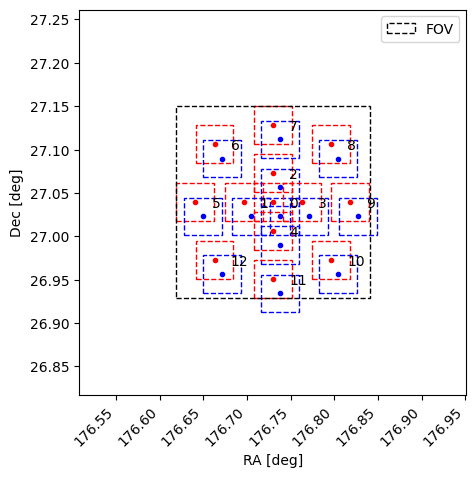

In [6]:
''' Plot the array location pattern on the VISDA array '''
### This is for visualizing the pattern, only. (10,10)deg is a default central location. See function above. 

plt.figure(figsize=(5, 5))
ax = plt.subplot()

for i in range(num_observations):
    # loc = array_location(i) ### call the array_location() function above
    loc = array_location(i, ra_home=c.ra.deg * u.deg, dec_home=c.dec.deg * u.deg)
    ax.plot(loc[0].value,loc[1].value, 'r.')
    # ax.annotate(str(i), (loc[0].value+0.01,loc[1].value+0.01))

    # Add the box
    box_width = (100 * 0.78 * u.arcsec).to(u.degree).value * 2
    box_height = box_width
    box_left = loc[0].value - (100 * 0.78 * u.arcsec).to(u.degree).value
    box_bottom = loc[1].value - (100 * 0.78 * u.arcsec).to(u.degree).value
    rect = plt.Rectangle((box_left, box_bottom), box_width, box_height,
                        fill=False, edgecolor='red', linestyle='--')
    ax.add_patch(rect)

    loc2 = array_location(i, ra_home=c2.ra.deg * u.deg, dec_home=c2.dec.deg * u.deg)
    ax.plot(loc2[0].value,loc2[1].value, 'b.')
    ax.annotate(str(i), (loc2[0].value+0.01,loc2[1].value+0.01))

    # Add the box
    box_width = (100 * 0.78 * u.arcsec).to(u.degree).value * 2
    box_height = box_width
    box_left = loc2[0].value - (100 * 0.78 * u.arcsec).to(u.degree).value
    box_bottom = loc2[1].value - (100 * 0.78 * u.arcsec).to(u.degree).value
    rect = plt.Rectangle((box_left, box_bottom), box_width, box_height,
                        fill=False, edgecolor='blue', linestyle='--')
    ax.add_patch(rect)

# Add the box
box_width = (512 * 0.78 * u.arcsec).to(u.degree).value * 2
box_height = box_width
box_left = c.ra.deg - (512 * 0.78 * u.arcsec).to(u.degree).value
box_bottom = c.dec.deg - (512 * 0.78 * u.arcsec).to(u.degree).value

rect = plt.Rectangle((box_left, box_bottom), box_width, box_height,
                     fill=False, edgecolor='black', linestyle='--', label='FOV')
ax.add_patch(rect)

plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')

VIS_shape_deg = VIS_ra_shape.to(u.degree) ### set plot limits to the shape of VISDA
plt.xlim(c.ra.deg - (1024*.78*u.arcsec).to(u.degree).value, c.ra.deg + (1024*.78*u.arcsec).to(u.degree).value)
plt.ylim(c.dec.deg - (1024*.78*u.arcsec).to(u.degree).value, c.dec.deg + (1024*.78*u.arcsec).to(u.degree).value)


# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.show()

## The rest of this notebook should be run for each of the 13 observations. Select an observation number

sim.observe() and sim.show_ROI() may fail when the observation number is > 0, i.e., the primary target is not at the center of the VISDA array. The sim.observe() issue is documented in PandoraSim issue 14: https://github.com/PandoraMission/pandora-sim/issues/14 

In [7]:
''' Only 0 runs right now. There is an open GitHub issue to help resolve this. Check there. '''
observation_number = 0

## Data Volume

Here, we estimate data volume based on obseravtion parameters and estimated rates and sizes. Currently, we're storing data volume constants in CommissFunctions.py, but we my want to store those elsewhere where everyone can reference the most recent numbers.

In [8]:
''' this sets observing parameters for the task '''
VIS_xpix              = 200 ### saving two 200x200 regions
VIS_ypix              = 200 
regions               = 2  
frames_per_int        = 1
num_int               = 600 

''' Calculating data volumes -- for 1 observation, i.e., 1 array location'''
int_and_reset_time    = frame_time_VIS * frames_per_int
bits_per_int          = VIS_xpix * VIS_ypix * regions * bits_per_pix_VIS * stored_frames_per_int_VIS
bits_per_sec          = bits_per_int / int_and_reset_time
test_time             = num_int * int_and_reset_time ### seconds
bits_per_sec_comp     = bits_per_sec / compression_fractor_VIS
bits_test_total       = bits_per_sec_comp * test_time
Gbits_test_packet     = bits_test_total / 1E9 * 1.1 * 1.25
downlinks             = Gbits_test_packet * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('test time, one observation:', test_time/60, 'minutes')
print(Gbits_test_packet, 'Gbits')
print(downlinks, 'downlinks')

print('.')
print('.')
print('.')

print(f'data volume, total: {Gbits_test_packet*num_observations}')
print('test time, total (not accounting for slew time):', test_time*num_observations/60, 'minutes')
print('downlinks, total:', downlinks*num_observations)

test time, one observation: 2.0 minutes
0.7040000000000001 Gbits
0.29333333333333333 downlinks
.
.
.
data volume, total: 9.152000000000001
test time, total (not accounting for slew time): 26.0 minutes
downlinks, total: 3.8133333333333335


## Run Simulation

For now, we select an arbitrary primary target. The secondary target is selected by pandorasim and is the next brightest object in frame. 

In [9]:

''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta


''' Initialize a simulator object '''
### Set the number of ROIs and their sizes
sim = VisibleSim(ROI_size=(VIS_xpix, VIS_ypix), nROIs=regions) 

Output()

In [10]:
observation_number = 11

In [11]:
''' Define the center of our observation based on primary target location and observation number '''
location = array_location(observation_number, c.ra, c.dec)
ra0      = location[0] 
dec0     = location[1] 
theta0   = 0*u.deg ### theta is currently arbitrary 


''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
# sim.point(ra0, dec0, -40*u.deg)
sim.point(ra0, dec0, 90*u.deg)

Output()

Output()

Output()

In [12]:
''' sim has various attributes you can print out '''
#print(sim.ra, sim.dec, sim.wcs)

''' Notably we have a Catalog of objects visable in the VIS FOV '''
cat = sim.source_catalog
#print(cat)

In [13]:
''' identify the correct ROIs based on the locations of our two targets '''
### This will set the ROI locations given an observation number and our two targets. 
# By default, one ROI is at the center and the second is centered at the next brightest target.
# We instead want to define our own locations. This cell moves one ROI to our primary target. 
# The secondary target is still default the brightest object. 
###

if observation_number>0:
    for i in range(len(cat)):
        ### search the catalog our primary target based on its coordinates. Coordinates are not exact, so we round to 2 decimals.
        if round(c.ra.value,2)==round(cat.ra[i],2) and round(c.dec.value,2)==round(cat.dec[i],2):
            print('Match! Cat index: ', i)
            cat_index = i
    
    ### set corner of primary ROI  
    sim.ROI_corners[0] = (cat.row[cat_index]-(VIS_xpix/2), cat.column[cat_index]-(VIS_ypix/2)) 


print('ROI locations [pix]: ', sim.ROI_corners)


''' Save ROI locations in sky coordinates for later '''
### Once the above update is made, we may do this differently.
ROI0_coord = sim.pixel_to_world(sim.ROI_corners[0][0], sim.ROI_corners[0][1])
ROI1_coord = sim.pixel_to_world(sim.ROI_corners[1][0], sim.ROI_corners[1][1])

Match! Cat index:  10
ROI locations [pix]:  [(920.365355444166, 1332.1905681248409), (957, 1256)]


## Observation

<Axes: title={'center': 'VISDA\n(RA:176.73 deg, Dec:26.95 deg, Roll:90.00 deg)'}, xlabel='Column [pixel]', ylabel='Row [pixel]'>

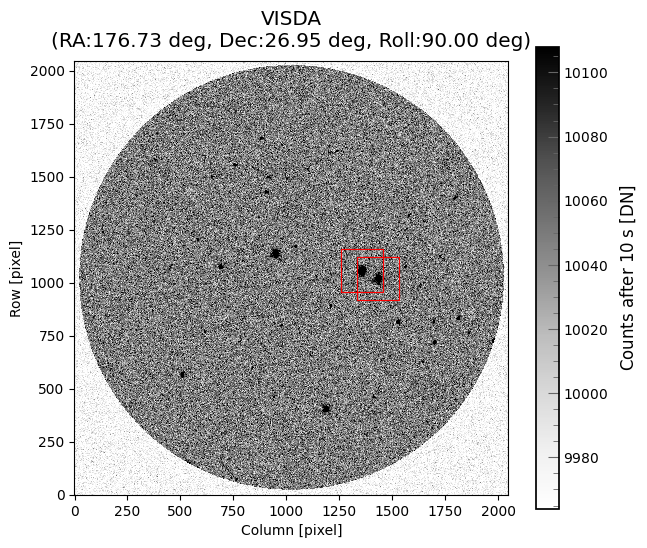

In [14]:
''' Plot the Full Frame Image. ROIs are in red boxes defining the subarray. '''
sim.show_FFI()

In [17]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

data = sim.observe(nreads=frames_per_int, bin_frames=1, nframes=num_int, start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|██████████| 13/13 [00:00<00:00, 32.54it/s]


(2, 600, 100, 100)

array([[<Axes: ylabel='Row\n[subarray pixel]'>, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

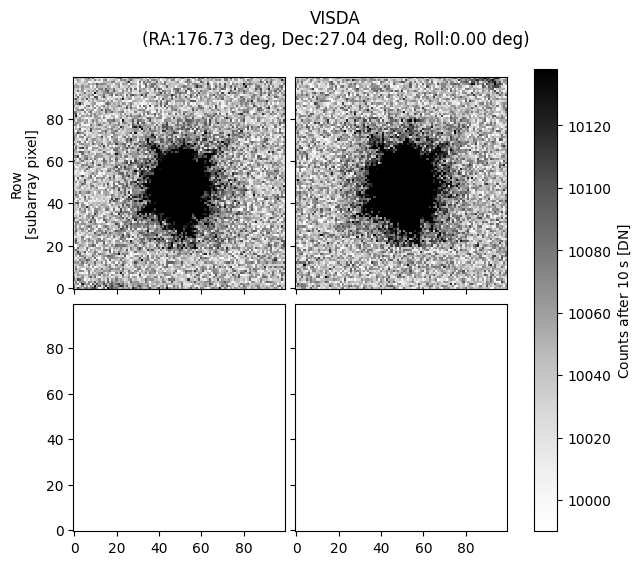

In [18]:
''' Plot our ROIs (regions of interest). ''' 
### THIS ONLY WORKS FOR OBS 0
# When obs > 0, this still plots the center of VISDA as an ROI. 
###
sim.show_ROI()

## Save the simulated observation

This .fits file cannot be uploaded to GitHub! They can instead be saved on Box.

In [19]:
''' Re-Create the observation in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
hdulist = sim.observe(nreads=frames_per_int, nframes=num_int, bin_frames=1, start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
rois_outfile = "3.15_rois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist.writeto(rois_outfile, overwrite=True)

Modeling Pixel Positions: 100%|██████████| 15/15 [00:00<00:00, 34.50it/s]


In [20]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(rois_outfile)
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

Filename: 3.15_rois_G4017930742788615552_obs0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  SCIENCE       1 ImageHDU        71   (200, 200, 600)   int64   
  2  ROITABLE      1 BinTableHDU     22   2R x 2C   [D, K]   
None


## Data Product

### RD-B1: create a PSF shape data cube 

A datacube containing the expected Point Spread Function (PSF) 2D shape as a function of i) position on the detector ii) wavelength iii) temperature of the optics(?). This will be used by the pipeline to a) create simulated data and b) to identify optimal extraction apertures. This product may be built from models, and may be informed and validated by ground tests and commissioning tests.

Right now, we aren't including much here, but we can develop this further if it would be useful. 

## Generate SOC File

### To run all 13 observations together

In [15]:
for i in range(num_observations):
    observation_number=i
    loc = array_location(i, ra_home=c.ra.deg * u.deg, dec_home=c.dec.deg * u.deg)
    print(f"Obs {observation_number:03}")

    '''Here we define the information required for scheduling the observation.'''
    ### Some variables may be removed/added/changed. Working on defining these with SOC meetings. 

    variables = {
        'ffi_flag': 0, # this task does not require full frame images
        'visit_id': '0315', ### setting based on task number. Could change. 
        'obs_id': f"{observation_number:03}", ### setting based on dither number. 
        'target': target, 
        'priority': 1, 
        'start_time': start_time, 
        'stop_time': end_time, 
        'RA': loc[0], # this adjusts with each observation to develop pattern
        'DEC': loc[1], # this adjusts with each observation to develop pattern
        'NIR_AvgGroups': '', ### no NIR. 
        'NIR_ROI_StartX': '', 
        'NIR_ROI_StartY': '', 
        'NIR_ROI_SizeX': '', 
        'NIR_ROI_SizeY': '',
        'NIR_SC_Resets1': '',
        'NIR_SC_Resets2': '', 
        'NIR_SC_DropFrames1': '',
        'NIR_SC_DropFrames2': '',
        'NIR_SC_DropFrames3': '', 
        'NIR_SC_ReadFrames': '',
        'NIR_targetID': '', 
        'NIR_SC_Groups': '',
        'NIR_SC_Integrations': '', 
        'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
        'VIS_FramesPerCoadd': frames_per_int, 
        'VIS_NumTotalFramesRequested': num_int, 
        'VIS_TargetRA': c.ra, 
        'VIS_TargetDEC': c.dec, 
        'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
        'VIS_StarRoiDimension': [VIS_xpix, VIS_ypix], 
        'VIS_MaxNumStarRois': '', ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
        'VIS_numPredefinedStarRois': regions, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
        'VIS_PredefinedStarRoiRa': [c.ra.deg, c2.ra.deg], ### currently defining as corner of ROI. We'll update this to be ROI centers.
        'VIS_PredefinedStarRoiDec': [c.dec.deg, c2.dec.deg], 
        'VIS_targetID': target, 
        'VIS_NumExposuresMax': num_int, 
        'VIS_ExposureTime_us': frame_time_VIS * 1000000  
    }

    '''Generate the SOC .xml file'''

    output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_example_SOC.xml' 
    generate_task_plan(variables, output_soc_file)
    

Obs 000
Obs 001
Obs 002
Obs 003
Obs 004
Obs 005
Obs 006
Obs 007
Obs 008
Obs 009
Obs 010
Obs 011
Obs 012


### For a single observation

In [21]:
'''Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. Working on defining these with SOC meetings. 

variables = {
    'visit_id': '0315', ### setting based on task number. Could change. 
    'obs_id': f"{observation_number:03}", ### setting based on dither number. 
    'target': target, 
    'priority': 1, 
    'start_time': start_time, 
    'stop_time': end_time, 
    'RA': c.ra,
    'DEC': c.dec, 
    'NIR_AvgGroups': '', ### no NIR. 
    'NIR_ROI_StartX': '', 
    'NIR_ROI_StartY': '', 
    'NIR_ROI_SizeX': '', 
    'NIR_ROI_SizeY': '',
    'NIR_SC_Resets1': '',
    'NIR_SC_Resets2': '', 
    'NIR_SC_DropFrames1': '',
    'NIR_SC_DropFrames2': '',
    'NIR_SC_DropFrames3': '', 
    'NIR_SC_ReadFrames': '',
    'NIR_targetID': '', 
    'NIR_SC_Groups': '',
    'NIR_SC_Integrations': '', 
    'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': frames_per_int, 
    'VIS_NumTotalFramesRequested': num_int, 
    'VIS_TargetRA': c.ra, 
    'VIS_TargetDEC': c.dec, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [VIS_xpix, VIS_ypix], 
    'VIS_MaxNumStarRois': '', ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': regions, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': [ROI0_coord[0], ROI1_coord[0]], ### currently defining as corner of ROI. We'll update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': [ROI0_coord[1], ROI1_coord[1]], 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': num_int, 
    'VIS_ExposureTime_us': frame_time_VIS * 1000000  
}

In [22]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_example_SOC.xml' 
generate_task_plan(variables, output_soc_file)